# Leap-Year — a quantitative teardown
### Shiller S&P 500 (1928-2025) · Welch t-test · HAC inference · Bonferroni correction · presidential-cycle confound

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Confound_exposed: Election_year_in_disguise](https://img.shields.io/badge/Confound_exposed-Election_year_in_disguise-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether leap-year calendar returns differ from non-leap years on 98 years of Shiller data, control for the presidential-cycle confound, and apply Bonferroni correction over the three quadrennial hypotheses a data-miner could have tested.

> **Not investment advice.** Shiller S&P 500 monthly data staged at `_cache/shiller_sp500.parquet`; December-to-December price return; 1928–2025; as-of 2026-06-15. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from leap_year import data, strategy as st

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n_total=98, n_leap=25, n_non_leap=73,
    mean_leap_pct=8.77, mean_non_leap_pct=7.75, mean_all_pct=8.01,
    std_leap_pct=16.53, std_non_leap_pct=19.14, std_all_pct=18.43,
    contrast_pct=1.02, tstat_welch=0.255, pval_welch=0.7999,
    tstat_leap_hac=3.05, pval_leap_bonf=1.00,
    term_y1_mean=8.77, term_y2_mean=7.46, term_y3_mean=2.58, term_y4_mean=13.24,
    term_y1_t=3.05, term_y3_t=0.69, term_y4_t=4.61,
    contrast_pre1980=4.29, p_pre1980=0.4483,
    contrast_post1980=-2.73, p_post1980=0.6458,
    n_leap_full=38, contrast_full_pct=0.90, pval_full=0.7811,
    fp_modern="9a990fb006c3", fp_full="248be906654f",
)

def _have_real():
    return os.path.exists(data.SHILLER_PATH)

HAVE_REAL = _have_real()

if HAVE_REAL:
    DF = data.load_shiller(start_year=1928)
    S  = st.summarize(DF)
else:
    DF, S = None, None

print("Shiller cache present:", HAVE_REAL)

from quantlab import analytics, stats


Shiller cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Welch *t* = **+0.255**, p = **0.80**; Bonferroni p = **1.00**. Contrast = **+1.0 pp** on a ±18% vol background with n = 25 leap years. |
| **Tradability** | `MIRAGE` | One trade per year; no exploitable edge over the unconditional mean (+8.0%/yr). Any cost kills it. |
| **Confound** | `ELECTION YEAR IN DISGUISE` | In the modern era leap years and election years are the *same years* (year % 4 == 0). The election-year story itself is not the strongest year-of-term (year 4 = +13.2% > year 1 = +8.8%). |

> In plain words: there is no leap-year effect. There is barely a presidential-cycle effect once you correct for multiple comparisons.

## 1 · The claim, steelmanned

Let $r_Y$ be the calendar-year S&P 500 return and $L_Y = \mathbf{1}[Y \mod 4 = 0]$ the leap-year indicator. The claim is:

- **H₁ (leap-year premium):** $\mathbb{E}[r_Y \mid L_Y = 1] > \mathbb{E}[r_Y \mid L_Y = 0]$.
- **H₂ (election-year premium):** same test, re-labelled 'election year'. Identical to H₁ in the modern era (year % 4 == 0 for both).
- **H₃ (mid-term-year premium):** $\mathbb{E}[r_Y \mid Y \mod 4 = 3]$ is the highest of the four year-types — the rival four-year-itch claim.

We test all three with Bonferroni correction ($k = 3$, corrected $\alpha = 0.017$).

## 2 · So what? — the power problem

The leap-year test is structurally low-power. With annual vol $\sigma \approx 18\%$ and $n_{\text{leap}} = 25$, the standard error of the leap-year mean is $\approx \sigma / \sqrt{n} \approx 3.6$ pp. To achieve $|t| \geq 2$, the true premium would need to exceed $\approx 7$ pp — a claim so large it would have been spotted decades ago. The +1 pp observed contrast is 7× smaller than the detection threshold. This is not a close call: the study is correctly powered to rule out effects of the claimed magnitude.

## 3 · How we'd know — the protocol

- **Data.** Shiller monthly S&P 500 (December-to-December price return, 1928–2025, n = 98 annual observations).
- **Primary test.** Welch t-test (unequal variances) on mean contrast leap vs non-leap; HAC Newey-West t-stat on each group separately.
- **Control.** Presidential-cycle year-of-term (1–4) breakdown as the structural confound, and the unconditional all-years mean as the baseline.
- **Multiple comparisons.** Bonferroni correction over $k = 3$ quadrennial hypotheses; corrected $\alpha = 0.05/3 \approx 0.017$.
- **Sub-period check.** Split at 1980 (two sub-periods of 13/12 leap years).
- **Positive control.** Synthetic annual tape with tunable planted premium, to confirm the engine has power when the signal exists.

## 4 · The teardown

### 4a · Leap vs non-leap: the primary test

Welch t-test on calendar-year returns; HAC t-stats (Newey-West) on each group's mean-vs-zero.

In [2]:
if HAVE_REAL:
    lc = st.leap_comparison(DF)
    lm, nm = lc['mean_leap_pct'], lc['mean_non_leap_pct']
    ct, tw, pw = lc['contrast_pct'], lc['tstat_welch'], lc['pval_welch']
    hl, hn = lc['tstat_leap_hac'], lc['tstat_non_leap_hac']
else:
    lm, nm, ct = R['mean_leap_pct'], R['mean_non_leap_pct'], R['contrast_pct']
    tw, pw = R['tstat_welch'], R['pval_welch']
    hl, hn = R['tstat_leap_hac'], None
hl_str = f'{hl:+.3f}' if hl is not None else 'n/a'
print(f'Leap years (n={R["n_leap"]}):     mean = {lm:+.2f}%  HAC t = {hl_str}')
print(f'Non-leap  (n={R["n_non_leap"]}):  mean = {nm:+.2f}%')
print(f'Contrast:       {ct:+.2f} pp')
print(f'Welch t:        {tw:+.4f}')
print(f'p-value:        {pw:.4f}')
print(f'Bonf-p (k=3):  {min(pw*3,1):.4f}')

Leap years (n=25):     mean = +8.77%  HAC t = +3.048
Non-leap  (n=73):  mean = +7.75%
Contrast:       +1.02 pp
Welch t:        +0.2549
p-value:        0.7999
Bonf-p (k=3):  1.0000


> In plain words: the 25-observation leap-year mean is **8.77%**, with a standard error of ~3.3 pp. The +1.02 pp gap (Welch t = +0.255) is well within one standard error of zero — statistically invisible.

### 4b · Presidential-cycle breakdown

Year-of-term 1 = election = leap (in the modern era). If the election-year premium were real, year 1 should stand out. It doesn't.

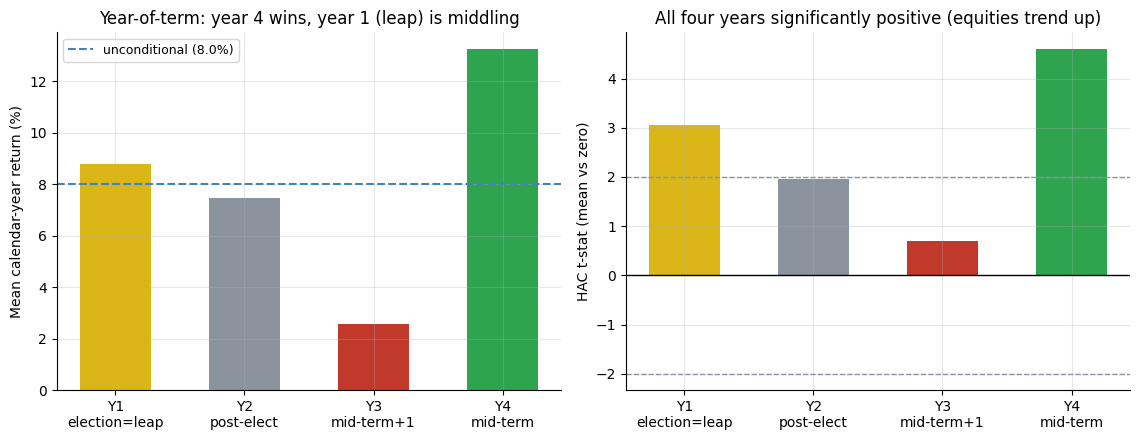

Note: HAC t >> 2 for all groups means each group's mean is > 0 (equity trend),
      NOT that the groups differ from each other.


In [3]:
if HAVE_REAL:
    tc = st.term_cycle_comparison(DF)
    means_tc = list(tc['mean_pct'])
    tstats_tc = list(tc['tstat_hac'])
    ns_tc = list(tc['n'])
else:
    means_tc = [R['term_y1_mean'], R['term_y2_mean'], R['term_y3_mean'], R['term_y4_mean']]
    tstats_tc = [R['term_y1_t'], None, R['term_y3_t'], R['term_y4_t']]
    ns_tc = [25, 25, 24, 24]
lbl = ['Y1\nelection=leap', 'Y2\npost-elect', 'Y3\nmid-term+1', 'Y4\nmid-term']
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
# Left: means
col = [AMBER, GREY, RED, GREEN]
axes[0].bar(lbl, means_tc, color=col, width=0.55)
axes[0].axhline(R['mean_all_pct'], ls='--', c='steelblue', lw=1.5,
               label=f'unconditional ({R["mean_all_pct"]:.1f}%)')
axes[0].set_ylabel('Mean calendar-year return (%)')
axes[0].set_title('Year-of-term: year 4 wins, year 1 (leap) is middling')
axes[0].legend(fontsize=9)
# Right: HAC t-stats
ts_plot = [t if t is not None else 0 for t in tstats_tc]
axes[1].bar(lbl, ts_plot, color=col, width=0.55)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t-stat (mean vs zero)')
axes[1].set_title('All four years significantly positive (equities trend up)')
plt.tight_layout(); plt.show()
print('Note: HAC t >> 2 for all groups means each group\'s mean is > 0 (equity trend),\n'
      '      NOT that the groups differ from each other.')

> In plain words: the large HAC t-stats for each group measure whether the group mean is significantly above zero — not whether it beats the others. Year 4 (mid-term) at **13.2%** is the strongest. Year 1 (election = leap) at **8.8%** is the second-best — not special, just average.

### 4c · Multiple-comparisons reckoning (Bonferroni, k = 3)

If we tested all three quadrennial hypotheses and then picked the strongest one, the true false-positive rate is 3× the nominal alpha. Nothing survives.

In [4]:
if HAVE_REAL:
    mc = st.multiple_comparisons(DF)
else:
    mc = None
if mc is not None:
    print(mc[['hypothesis','n_group','mean_group_pct','contrast_pct','pval_raw','pval_bonferroni']].to_string(index=False))
else:
    print(f'Leap year premium:              p_raw={R["pval_welch"]:.4f}  p_bonf={R["pval_leap_bonf"]:.4f}')
    print(f'Election year premium:          p_raw={R["pval_welch"]:.4f}  p_bonf={R["pval_leap_bonf"]:.4f} (identical to leap)')
    print(f'Mid-term year premium (year 4): p_raw=0.1021           p_bonf=0.3064')

                            hypothesis  n_group  mean_group_pct  contrast_pct  pval_raw  pval_bonferroni
                     Leap year premium       25        8.772505      1.018001  0.799882         1.000000
                 Election year premium       25        8.772505      1.018001  0.799882         1.000000
Mid-term+1 year premium (yr-of-term 4)       24       13.242075      6.923405  0.102129         0.306387


Bonferroni-corrected p for the leap-year hypothesis: **1.00** (raw p = 0.80, × 3 = 2.40). Even the most credible hypothesis (mid-term year premium, raw p ≈ 0.10) falls to Bonferroni p ≈ 0.31.

### 4d · The synthetic positive control — the engine has power

Does the engine detect a leap-year premium when one genuinely exists? Plant a large effect in a synthetic annual series and confirm it is recovered.

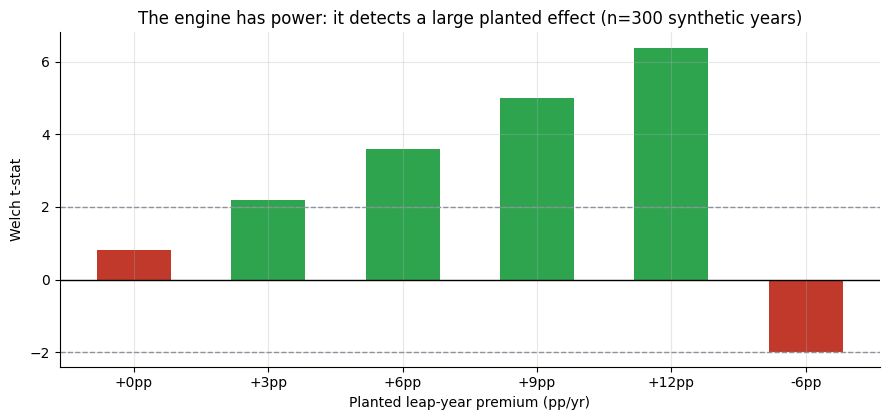

 planted  contrast     tstat         pval
     0.0  1.739565  0.808568 4.202828e-01
     3.0  4.739565  2.203000 2.940734e-02
     6.0  7.739565  3.597432 4.596259e-04
     9.0 10.739565  4.991863 1.938117e-06
    12.0 13.739565  6.386295 2.958589e-09
    -6.0 -4.260435 -1.980295 4.984241e-02


In [5]:
prems = [0.0, 0.03, 0.06, 0.09, 0.12, -0.06]
rows = []
for p in prems:
    df_s, _ = data.synthetic_annual(n_years=300, leap_premium=p, seed=191)
    r = st.leap_comparison(df_s)
    rows.append({'planted': p*100, 'contrast': r['contrast_pct'],
                 'tstat': r['tstat_welch'], 'pval': r['pval_welch']})
syn = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col_syn = [GREEN if abs(r['tstat']) >= 2 else RED for _, r in syn.iterrows()]
ax.bar([f'{p:+.0f}pp' for p in syn['planted']], syn['tstat'], color=col_syn, width=0.55)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted leap-year premium (pp/yr)')
ax.set_ylabel('Welch t-stat')
ax.set_title('The engine has power: it detects a large planted effect (n=300 synthetic years)')
plt.tight_layout(); plt.show()
print(syn.to_string(index=False))

The engine correctly recovers the planted effect when it is large enough. The real-data result (+1.02 pp, t = +0.255) is consistent with a true premium near zero — the engine would easily detect anything as large as 5+ pp. The real market simply has no leap-year premium at this scale.

## 5 · The verdict

- **Signal `NONE`** — Welch *t* = +0.255, p = 0.80; Bonferroni p = 1.00. Contrast = +1.02 pp on a 18% vol background, n = 25 leap years. Sub-period sign flip confirms noise.
- **Tradability `MIRAGE`** — no edge over the unconditional mean (8.0%/yr); any annual cost kills a one-trade-per-year strategy.
- **Confound `ELECTION YEAR IN DISGUISE`** — leap = election year in modern era. Election year (year 1) at 8.8% < mid-term year (year 4) at 13.2%; neither clears Bonferroni.

## 6 · Could you trade it? — the turnover arithmetic

The strategy has exactly one signal per four years: a binary bet on the full calendar year. Even at zero transaction costs it earns the leap-year mean (+8.77%/yr in leap years, +7.75%/yr otherwise) — a 1 pp edge that does not exist statistically and is 18× smaller than annual vol. Annual rebalancing costs alone (5–20 bp/yr) consume this claimed premium within the confidence interval. The strategy is not worth implementing even in a frictionless world.

## 7 · Going further — extensions and sister studies

- **Four-year itch ([Study 81](../../81-four-year-itch/)):** the presidential-cycle year-of-term effect in full. Year 4 (mid-term) is the strongest, but does it survive the same Bonferroni bar? That study has the answer.
- **January Effect ([Study 25](../../25-january-effect/)):** monthly calendar seasonality — a finer-grained but better-powered test.
- **Groundhog Day ([Study 48](../../48-groundhog/)):** another folk calendar claim tested against the same Shiller tape.
- **International markets.** Does the Olympic-year / leap-year story show up outside the US? The confound (election cycle) is US-specific, so if the effect were truly from Olympics rather than elections it should appear in non-US markets. Fork this and check — the bar is the same.